# Buiness Understanding & Project Scope
---

## Business Background
PT XYZ merupakan perusahaan fast-moving consumer goods terkemuka yang mengoperasikan portofolio produk multi-kategori guna memenuhi kebutuhan pasar domestik secara luas. Sejalan dengan visi strateginya, perusahaan berkomitmen untuk mengoptimalkan seluruh rantai pasok ekosistemnya sembari memberdayakan para pelaku usaha dan mitra hulu di tingkat akar rumput.


Setelah melalui beberapa periode operasional awal, manajemen mengidentifikasi adanya variabilitas yang tinggi pada biaya logistik, risiko kualitas material, serta ketidakpastian waktu tunggu pengiriman. Oleh karena itu, proyek analitik ini diinisiasi untuk merancang solusi integratif yang berfokus pada efisiensi biaya dan mitigasi risiko operasional pada sektor rantai pasok perusahaan dari hulu ke hilir.

## Problem Statement & Objectives
Proyek ini bertujuan untuk menjawab tantangan operasional utama PT XYZ melalui pendekatan kuantitatif. Secara spesifik, sasaran strategis dari proyek analitik ini adalah:
1. Inventory Optimization : Menyeimbangkan tingkat ketersediaan produk dan meminimalkan probabilitas kehabisan stok melalui kalkulasi safety stock dan reorder point yang dinamis.
2. Quality Risk dan COPQ Mitigation : Memetakan performa vendor untuk mengidentifikasi pembengkakan biaya akibat cacat produksi melalui analisis Cost of Poor Quality (COPQ)
3. Strategic Logistics Allocation: Merancang skenario alokasi rute, kurir, dan volume pasokan yang menghasilkan biaya logistik paling minimum dengan menggunakan pemodelan matematika linear programming.
4. Executive data storytelling: Menerjemahkan hasil keputusan optimal ke dalam bentuk executive dashboard interaktif (platform data studio) untuk membandingkan performa sebelum versus sesudah optimasi.

## Project Scope & Framework Boundary
Untuk menjaga validitas dan fokus analitik, batasan ruang lingkup proyek ditetapkan sebagai berikut:
- Analisis menggunakan dataset snapshot operasional menyeluruh yang mencakup metrik komersial, biaya manufaktur, performa supplier, hingga logistik pengiriman.
- Pendekatan analisis menggunakan prinsip manajemen operasi yang sensitif terhadap variabilitas waktu, hambatan kapasitas produksi, serta kualitas produk.
- Proyek ini berfokus pada Prescriptive Analytics menggunakan optimasi matematika deterministik dan pemodelan statistik makro, bukan pemodelan prediksi deret waktu.

## Resource & Tool Stack
Untuk mengetahui pipeline analitik dari hulu ke hilir, proyek ini memanfaatkan ekosistem instrumen berikut:
- Data source: Dataset rantai pasok FMCG [Open Source Repository Kaggle](https://www.kaggle.com/datasets/harshsingh2209/supply-chain-analysis)
- Bahasa pemograman utama/IDE : Python dan google colab environment
- Data manipulation & exploration: pandas, numpy
- Statistical Analytics & Data Science: Scipy.stats, scikit learn.
- Visualizations : matplotlib, seaborn
- Operations research/Optimization: PuLP / scipy.optimize
- Business intelligence platgorm : google data studio


## Feature yang terdapat pada data yang akan di analisis
* Product Type
* SKU
* Price
* Availability
* Number of products sold
* Revenue generated
* Customer demographics
* Stock levels
* Lead times
* Order quantities
* Shipping times
* Shipping carriers
* Shipping costs
* Supplier name
* Location
* Lead time
* Production volumes
* Manufacturing lead time
* Manufacturing costs
* Inspection results
* Defect rates
* Transportation modes
* Routes
* Costs

# Environment Setup & Dependencies
---

In [1]:
# Installing External Packages
# Menginstall pulp untuk pemodelan riset operasi
!pip install pulp -q

In [2]:
# Importing libraries
import pandas as pd
import numpy as np
import scipy.stats as stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pulp
import matplotlib.pyplot as plt
import seaborn as sns

#Mengatur visualiasi agar terlihat rapi dan professional
%matplotlib inline
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Data Loading & Understanding
---

In [3]:
url = "https://raw.githubusercontent.com/Marsello-or/Supply_Chain_Analysis/refs/heads/main/Data/supply_chain_data.csv"
df = pd.read_csv(url)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    object 
 1   SKU                      100 non-null    object 
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 non-null    int64  
 5   Revenue generated        100 non-null    float64
 6   Customer demographics    100 non-null    object 
 7   Stock levels             100 non-null    int64  
 8   Lead times               100 non-null    int64  
 9   Order quantities         100 non-null    int64  
 10  Shipping times           100 non-null    int64  
 11  Shipping carriers        100 non-null    object 
 12  Shipping costs           100 non-null    float64
 13  Supplier name            100 non-null    object 
 14  Location                 10

Hasil peninjauan struktur dan tipe data menunjukkan bahwa data yang digunakan sudah cukup sesuai dengan nama fitur serta dengan tipe data yang ada pada dataframe.

In [5]:
display(df.describe(include=[np.number]))

,Price,Availability,Number of products sold,Revenue generated,Stock levels,Lead times,Order quantities,Shipping times,Shipping costs,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Defect rates,Costs
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000
mean,49.462461,48.400000,460.990000,5776.048187,47.770000,15.960000,49.220000,5.750000,5.548149,17.080000,567.840000,14.77000,47.266693,2.277158,529.245782
std,31.168193,30.743317,303.780074,2732.841744,31.369372,8.785801,26.784429,2.724283,2.651376,8.846251,263.046861,8.91243,28.982841,1.461366,258.301696
min,1.699976,1.000000,8.000000,1061.618523,0.000000,1.000000,1.000000,1.000000,1.013487,1.000000,104.000000,1.00000,1.085069,0.018608,103.916248
25%,19.597823,22.750000,184.250000,2812.847151,16.750000,8.000000,26.000000,3.750000,3.540248,10.000000,352.000000,7.00000,22.983299,1.009650,318.778455
50%,51.239831,43.500000,392.500000,6006.352023,47.500000,17.000000,52.000000,6.000000,5.320534,18.000000,568.500000,14.00000,45.905622,2.141863,520.430444
75%,77.198228,75.000000,704.250000,8253.976921,73.000000,24.000000,71.250000,8.000000,7.601695,25.000000,797.000000,23.00000,68.621026,3.563995,763.078231
max,99.171329,100.000000,996.000000,9866.465458,100.000000,30.000000,96.000000,10.000000,9.929816,30.000000,985.000000,30.00000,99.466109,4.939255,997.413450


Deskripsi data kuantitatif dari dataset menunjukkan persebaran yang normal dan tidak diperlukan adanya tahapan cleaning lanjutan.

In [6]:
display(df.describe(include=[object]))

,Product type,SKU,Customer demographics,Shipping carriers,Supplier name,Location,Inspection results,Transportation modes,Routes
count,100,100,100,100,100,100,100,100,100
unique,3,100,4,3,5,5,3,4,3
top,skincare,SKU0,Unknown,Carrier B,Supplier 1,Kolkata,Pending,Road,Route A
freq,40,1,31,43,27,25,41,29,43


In [7]:
categorical_columns = [
    'Product type',
    'SKU',
    'Customer demographics',
    'Shipping carriers',
    'Supplier name',
    'Location',
    'Inspection results',
    'Transportation modes',
    'Routes'
]

for col in categorical_columns:
  print(df[col].value_counts())

Product type
skincare     40
haircare     34
cosmetics    26
Name: count, dtype: int64
SKU
SKU0     1
SKU1     1
SKU2     1
SKU3     1
SKU4     1
        ..
SKU95    1
SKU96    1
SKU97    1
SKU98    1
SKU99    1
Name: count, Length: 100, dtype: int64
Customer demographics
Unknown       31
Female        25
Non-binary    23
Male          21
Name: count, dtype: int64
Shipping carriers
Carrier B    43
Carrier C    29
Carrier A    28
Name: count, dtype: int64
Supplier name
Supplier 1    27
Supplier 2    22
Supplier 5    18
Supplier 4    18
Supplier 3    15
Name: count, dtype: int64
Location
Kolkata      25
Mumbai       22
Chennai      20
Bangalore    18
Delhi        15
Name: count, dtype: int64
Inspection results
Pending    41
Fail       36
Pass       23
Name: count, dtype: int64
Transportation modes
Road    29
Rail    28
Air     26
Sea     17
Name: count, dtype: int64
Routes
Route A    43
Route B    37
Route C    20
Name: count, dtype: int64


Berdasarkan analisis data kualitatif, data menunjukkan bahwa semua baris yang digunakan bersih dan tidak ada value yang tidak sesuai dengan deskripsi fitur.

# Exploratory Data Analysis (EDA)
---

In [8]:
# Menghitung cost of poor quality (COPQ) per baris data
# Rumus : Volume produksi * Biaya Produksi * Persentase Cacat

df['COPQ_Before'] = df['Production volumes'] * df['Manufacturing costs'] * (df['Defect rates']/100)

# Menghitung total biaya operasionak eksisting
# Rumus : (Volume produksi * Biaya produksi ) + Ongkos kirim eksisting
df['Total_Cost_Before'] = (df['Production volumes'] * df['Manufacturing costs']) + df['Shipping costs']
display(df[['SKU', 'Product type','COPQ_Before', 'Total_Cost_Before']].head())

,SKU,Product type,COPQ_Before,Total_Cost_Before
0,SKU0,haircare,22.528225,9953.130609
1,SKU1,skincare,843.630691,17389.586124
2,SKU2,haircare,1364.928048,29806.121266
3,SKU3,skincare,1584.449474,33382.112258
4,SKU4,skincare,1198.936896,38118.867036


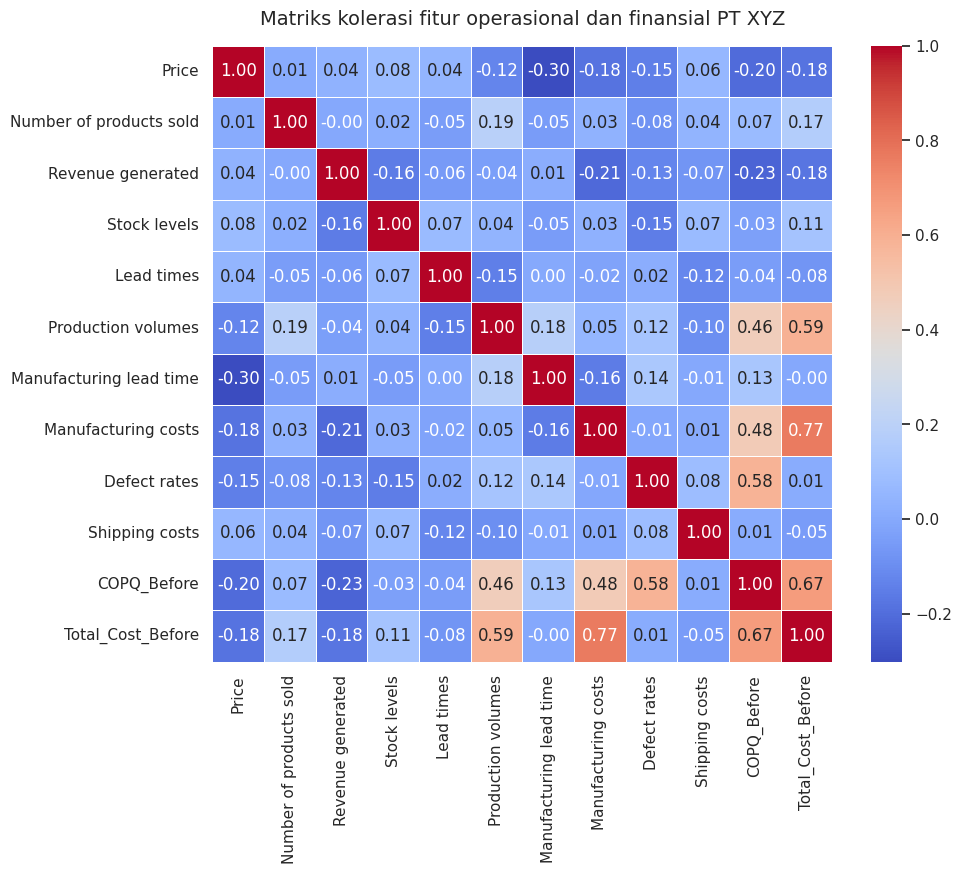

In [9]:
# Mencari korelasi antar biaya dan kualitas produk yang dihasilkan
core_numeric_cols = [
    'Price', 'Number of products sold', 'Revenue generated', 'Stock levels',
    'Lead times', 'Production volumes', 'Manufacturing lead time', 'Manufacturing costs','Defect rates',
    'Shipping costs', 'COPQ_Before', 'Total_Cost_Before'
]

# Menghtiung kolerasi pearson
correlation_matrix = df[core_numeric_cols].corr()

#Visualisasi heatmap korelasi
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidth=0.5)
plt.title("Matriks kolerasi fitur operasional dan finansial PT XYZ", fontsize=14, pad=15)
plt.show()

,Product type,Revenue generated,Total_Cost_Before,COPQ_Before,Number of products sold,Profit_Margin_Before(%)
0,cosmetics,161521.265999,5.519704e+05,7697.505005,11757,-241.732354
1,haircare,174455.390605,9.960798e+05,26335.887999,13611,-470.965317
2,skincare,241628.162133,1.175370e+06,28284.869672,20731,-386.437441


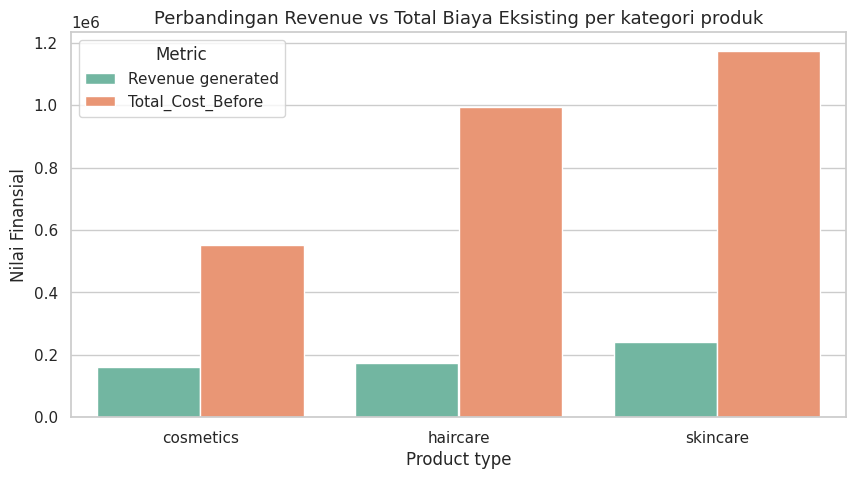

In [10]:
# Agregasi data berdasarkan tipe produk
product_perf = df.groupby('Product type').agg({
    'Revenue generated' : 'sum',
    'Total_Cost_Before' : 'sum',
    'COPQ_Before' : 'sum',
    'Number of products sold': 'sum'
}).reset_index()

# Menghitung margin keuntungan kasar eksisting (%)
product_perf['Profit_Margin_Before(%)'] = ((product_perf['Revenue generated'] - product_perf['Total_Cost_Before']) / product_perf['Revenue generated']) * 100
display(product_perf)

# Visualisasi komparasi revenue vs total cost
product_perf_melted = pd.melt(product_perf, id_vars=['Product type'], value_vars=['Revenue generated', 'Total_Cost_Before'], var_name='Metric', value_name='Amount')

plt.figure(figsize=(10, 5))
sns.barplot(data=product_perf_melted, x='Product type', y='Amount', hue='Metric', palette='Set2')
plt.title('Perbandingan Revenue vs Total Biaya Eksisting per kategori produk', fontsize=13)
plt.ylabel('Nilai Finansial')
plt.show()

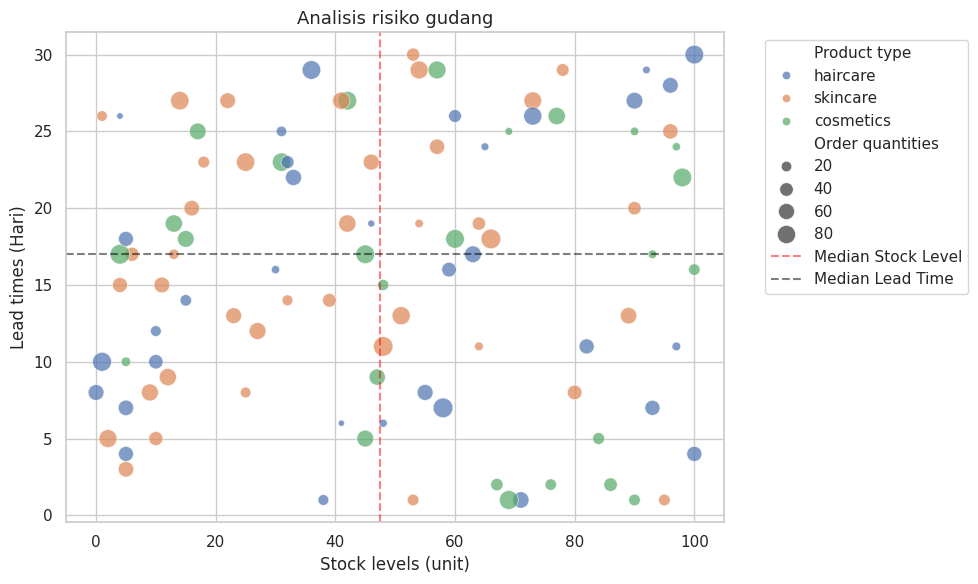

In [11]:
# Analisis risiko gudang (lead times x stock levels)

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Stock levels', y='Lead times', hue='Product type', size='Order quantities', sizes=(20, 200), alpha=0.7)
plt.axvline(x=df['Stock levels'].median(), color='red', linestyle='--', alpha=0.5, label='Median Stock Level')
plt.axhline(y=df['Lead times'].median(), color='black', linestyle='--', alpha=0.5, label='Median Lead Time')

plt.title('Analisis risiko gudang', fontsize=13)
plt.xlabel('Stock levels (unit)')
plt.ylabel('Lead times (Hari)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Kesimpulan Visualisasi EDA

1. Korelasi tinggi antara manufacturing cost dengan COPQ dan Total Cost bersifat matematis karena variabel tersebut merupakan komponen dasar penyusun rumus. Namun, inefisiensi riil terdeteksi dari korelasi positif antara Defect Rates dengan production volume serta manufacturing lead time, yang mengindikasikan bahwa peningkatan volume produksi dan waktu proses berisiko menurunkan kendali mutu produk.
2. Visualisasi ini menunjukkan masalah bisnis terbesar dan paling krusial dari PT XYZ, perusahaan terdeteksi mengalami kerugian besar di semua kategori produk.
    - Beban biaya (Total_Cost_Before) jauh lebih tinggi daripada pendapatan.
    - Kondisi paling parah ada pada kategori skincare dan haircare, di mana pengeluaran operasional mencapai hampir 5 sampai  kali lipat dari pendapatan yang dihasilkan.
3. Grafik ini menangkap dengan baik sebaran risiko stok barang. Berdasarkan visualisasi kuadran ke 2 (atas kiri) terdapat banyak titik (terutama skincare dan cosmetics) yang berada di area kritis (stok di bawah median 48 unit & lead time di atas median 17 hari). Jika ada lonjakan permintaan mendadak, area ini dipastikan langsung mengalami stockout karena supplier butuh waktu sangat lama untuk mengirimkan barang baru. Ukuran lingkaran yang bervariasi juga meunjukkan bahwa PT.XYZ saat ini memesan barang tanpa perhitungan kuantitatif yang jelas.


# Model Development (Klasifikasi untuk mengelompokkan produk)
---

In [12]:
# Memilih fitur komersial dan kualitas untuk segmentasi risiko produk
features_for_clustering = ['Revenue generated', 'Defect rates']
X = df[features_for_clustering]

# Inisialisasi dan fitting standardscaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

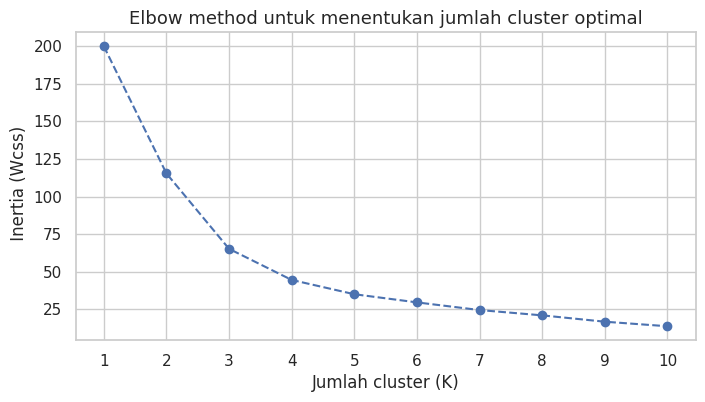

In [13]:
 # Menggunakan elbow method untuk menentukan jumlah cluster yang sesuai
inertia = []
K_range = range(1,11)

for k in K_range:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(X_scaled)
  inertia.append(kmeans.inertia_)

# Visualisasi hasil elbow method
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.title('Elbow method untuk menentukan jumlah cluster optimal', fontsize=13)
plt.xlabel('Jumlah cluster (K)')
plt.ylabel(' Inertia (Wcss)')
plt.xticks(K_range)
plt.show()

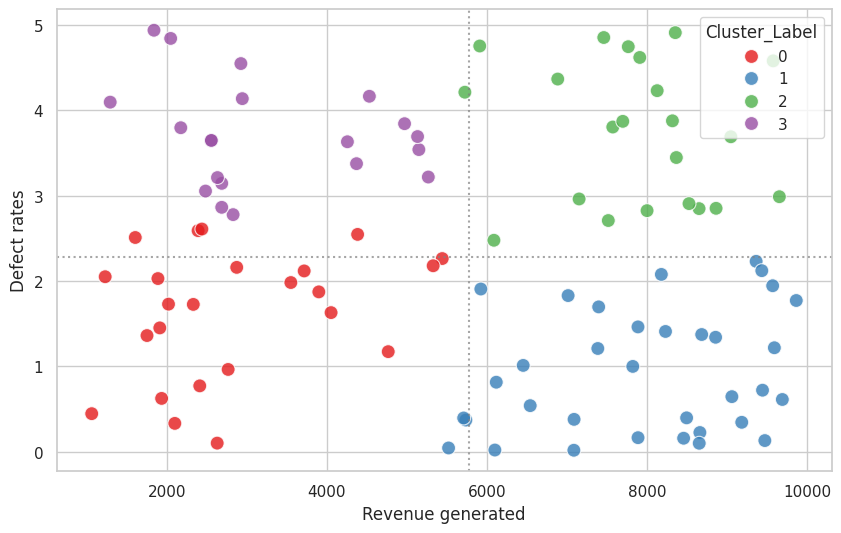

In [14]:
# Menjalankan K-Means dengan k = 4 berdasarkan hasil elbow mehtod
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster_Label'] = kmeans.fit_predict(X_scaled)

# Visualisasikan hasil cluster
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='Revenue generated',
    y='Defect rates',
    hue='Cluster_Label',
    palette='Set1',
    s=100,
    alpha=0.8
)

plt.axvline(x=df['Revenue generated'].mean(), color='gray', linestyle=':', alpha=0.7, label='Mean Revenue')
plt.axhline(y=df['Defect rates'].mean(), color='gray', linestyle=':', alpha=0.7, label='Mean Defect Rates')

Berdasarkan persebaran hasil klasifikasi dengan metode KMeans clustering, terdeteksi terdapat 4 kluster yang dibagi menjadi 4 kuadran yang secara spesifik menunjukkan kategori jenis produk:
  - Cluster 1 (Stars Product) yaitu produk dengan karakteristik high revenue dengan low defect rates, cluster 1 ini merupakan kelompok produk paling sehat dan menjadi penyokong utama finansial PT.XYZ, produk ini harus dijaga ketat ketersediaannya dan jangan sampai rute pengirimannya terlambat oleh masalah logistik.
  - Cluster 2 (Quality Risk) yaitu produk dengan karakteristik high revenue dengan high defect rates, difokuskan untuk tim quality control dan manufaktur hulu, agar proses produksi atau kualitas bahan baku dari supplier kelompok ini diaudit.
  - Cluster 3 (Operational Burden) yaitu produk dengan low revenue dan high defect rates, produk ini kurang laku di pasar tetapi operasional pabrik menghasilkan banyak barang cacat, sehingga membebani arus kas operasional. Dapat dipetimbangkan untuk efisiensi ekstrem, restrukturisasi vendor, atau pengehentian sementara guna menghemat anggaran.
  - Cluster 0 (Sleeper Product), produk low revenue dengan low defect rates, kualitas produknya sudah bagus dan aman, namun volume penjualannya masih rendah, dapat diserahkan ke tim marketing untuk ditingkatkan kembali strategi promosinya agar dapat naik kelas ke cluster 1.

In [15]:
# Membuat mapping cluster berdasarkan analisis kuaran
cluster_mapping = {
    1: 'Stars Product',
    2: 'Quality Risk',
    3: 'Operational Burden',
    0: 'Sleeper product'
}

df['product_segment'] = df['Cluster_Label'].map(cluster_mapping)

display(df[['SKU', 'Product type', 'Revenue generated', 'Defect rates', 'product_segment']].head(10))

# Membuat laporan teragregasi untuk laporan manajemen
cluster_summary = df.groupby('product_segment').agg(
    Jumlah_SKU = ('SKU', 'count'),
    Total_Revenue = ('Revenue generated', 'sum'),
    Rata_rata_defect = ('Defect rates', 'mean'),
    Total_COPQ_Eksisting = ('COPQ_Before', 'sum')
).reset_index()

display(cluster_summary)

,SKU,Product type,Revenue generated,Defect rates,product_segment
0,SKU0,haircare,8661.996792,0.226410,Stars Product
1,SKU1,skincare,7460.900065,4.854068,Quality Risk
2,SKU2,haircare,9577.749626,4.580593,Quality Risk
3,SKU3,skincare,7766.836426,4.746649,Quality Risk
4,SKU4,skincare,2686.505152,3.145580,Operational Burden
5,SKU5,haircare,2828.348746,2.779194,Operational Burden
6,SKU6,skincare,7823.476560,1.000911,Stars Product
7,SKU7,cosmetics,8496.103813,0.398177,Stars Product
8,SKU8,cosmetics,7517.363211,2.709863,Quality Risk
9,SKU9,skincare,4971.145988,3.844614,Operational Burden


,product_segment,Jumlah_SKU,Total_Revenue,Rata_rata_defect,Total_COPQ_Eksisting
0,Operational Burden,20,65334.863963,3.709523,22421.615108
1,Quality Risk,22,173184.073046,3.752360,19847.521153
2,Sleeper product,24,68489.925292,1.635345,13077.797696
3,Stars Product,34,270595.956437,0.933093,6971.328718


# Simulasi kemungkinan terjadinya stockout
Dengan mengambil asumsi bahwa fluktuasi dari jumlah barang dan waktu pengiriman kurir bervariase mengikuti distribusi normal, maka secara teori kita dapat memperkirakan terjadinya stockout dengan simulasi monte carlo.
  - menghasilkan angka acak untuk demand harian (product sold/day)
  - menghasilkan angka acak untuk lead time kurir
  - menghitung total kebutuhan barang selama masa tunggu kurir dengan rumus DDLT = Demand acak x lead time acak
  - kalau ddlt > stock maka terjadi stockout


In [16]:
num_simulations = 10000
np.random.seed(42)

stockout_probabilities = []

for idx, row in df.iterrows():
  # menghitung parameter statistik dari data, dengan asumsi variabilitas sebesar 20%
  mean_demand_daily  = row['Number of products sold'] / 30
  std_demand_daily = 0.2 * mean_demand_daily

  mean_lead_time = row['Lead time']
  std_lead_time = mean_lead_time * 0.2

  current_stock = row['Stock levels']

  sim_demand_daily = np.random.normal(mean_demand_daily, std_demand_daily, num_simulations)
  sim_lead_time = np.random.normal(mean_lead_time, std_lead_time, num_simulations)

  sim_demand_daily = np.clip(sim_demand_daily, 0, None)
  sim_lead_time = np.clip(sim_lead_time, 0, None)

  sim_ddlt = sim_demand_daily * sim_lead_time

  num_stockouts = np.sum(sim_ddlt > current_stock)

  prob_stockouts = num_stockouts / num_simulations * 100
  stockout_probabilities.append(prob_stockouts)

df['stockout_probability_before(%)'] = stockout_probabilities

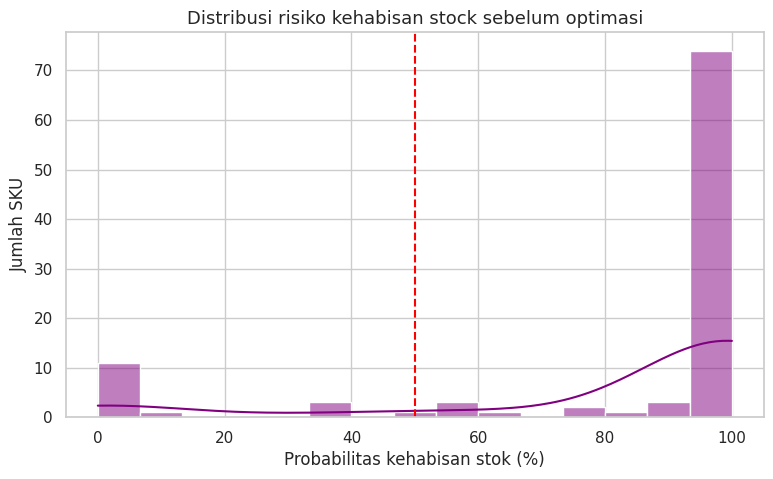

In [17]:
plt.figure(figsize=(9, 5))
sns.histplot(df['stockout_probability_before(%)'], bins=15, kde=True, color='purple')
plt.axvline(x=50, color='red', linestyle='--', label='Kritis (>50% probabilitas stockout)')
plt.title('Distribusi risiko kehabisan stock sebelum optimasi', fontsize =13)
plt.xlabel('Probabilitas kehabisan stok (%)')
plt.ylabel('Jumlah SKU')
plt.legend
plt.show()

Berdasarkan grafik visualisasi di atas, terdapat lonjakan batang raksasa di rentang 95-100% artinya ada sekitar 74 sku yang apabila didiamkan maka dengan kebijakan stok saat ini hampir pasti akan mengalami kehabisan barang di setiap siklus pemesanan ulang. Sementara itu hanya ada sekitar 10-11 sku yang berada di area 0-10%, produk pada arean inilah yang menyeimbangkan operasional dasar namun jumlahnya sangat sedikit.

Area tengah yang kosong menunjukkan bahwa manajemen inventaris tidak memiliki standarisasi, kalau produk tidak berada di area yang aman, maka sisanya hanya akan jatuh pada kondisi yang kritis.

Hal ini dapat terjadi karena beberapa point:
  - Sales velocity dan stock level yang tidak sebanding
  - Banyak sku yang memiliki lead time di atas median (>17 hari) sehingga waktu tunggu suplier tidak mencukupi untuk memenuhi demand yang ada
  

Ketika hal ini terjadi maka produk produk yang berada di cluster Stars akan kehilangan kesempatan untuk meraup keuntungan karena konsumen terpaksa pergi ke produk kompetitor, sementara itu untuk mengatasi stockout massal maka tim logistik atau warehousing terpaksa mengeluarkan biaya untuk pengiriman darurat melewati moda transportasi udara yang berbiaya mahal.

# Safety stock & Reorder point
---

dengan target service level sebesar 95% (Z score - 1.645) maka ditargetkan bahwa hanya ada 5% toleransi terhadap kemungkinan barang habis di dunia nyata.

Dengan rumus Safety Stock = Z x sqrt((AVG lead time x variance of daily demand) + (AVG daily demand^2 * variance of lead time))

Setelah mendapatkan safety stocknya kemudian bisa menentukan reorder point, yaitu batas stock level gudang yang menjadi alarm otomatis bagi tim procurement untuk segera membuat pesanan baru ke suppliar

ROP = (AVG demand daily x avg lead time) + Safety stock

In [18]:
import scipy.stats as stats
service_level = 0.95
Z_score = stats.norm.ppf(service_level)

safety_stocks = []
reoder_points = []

for idx, row in df.iterrows():
  mean_demand_daily = row['Number of products sold'] / 30
  std_demand_daily = mean_demand_daily * 0.20

  mean_lead_time = row['Lead time']
  std_lead_time = mean_lead_time * 0.20

  variance_component = (mean_lead_time * (std_demand_daily**2)) + ((mean_demand_daily**2) * (std_lead_time**2))
  ss = Z_score * np.sqrt(variance_component)

  rop = (mean_demand_daily * mean_lead_time) + ss

  safety_stocks.append(ss)
  reoder_points.append(rop)

df['ideal_safety_stock'] = safety_stocks
df['ideal_reorder_point'] = reoder_points

In [19]:
# Klasifikasi prioritas manajemen stock
# Perhitungan persentase kontribusi revenue setiap SKU
total_rev = df['Revenue generated'].sum()
df_sorted_abc = df.sort_values(by='Revenue generated', ascending=False)
df_sorted_abc['Cum_revenue_Pct'] = df_sorted_abc['Revenue generated'].cumsum() / total_rev * 100

def assign_abc(pct):
  if pct <= 70: return 'A (High value)'
  elif pct <= 90: return 'B (Medium Value)'
  else: return 'C (Low Value)'

df_sorted_abc['ABC_Class'] = df_sorted_abc['Cum_revenue_Pct'].apply(assign_abc)
df = df_sorted_abc.drop(columns=['Cum_revenue_Pct']).sort_index()

display(df[['SKU', 'Product type', 'Stock levels', 'ideal_safety_stock', 'ideal_reorder_point', 'ABC_Class']].head(10))

,SKU,Product type,Stock levels,ideal_safety_stock,ideal_reorder_point,ABC_Class
0,SKU0,haircare,58,259.400012,1034.666679,A (High value)
1,SKU1,skincare,53,189.619655,753.886321,A (High value)
2,SKU2,haircare,1,1.095691,4.295691,A (High value)
3,SKU3,skincare,23,22.294088,88.694088,A (High value)
4,SKU4,skincare,5,52.313621,197.480287,C (Low Value)
5,SKU5,haircare,90,16.906343,65.906343,C (Low Value)
6,SKU6,skincare,11,10.329017,40.662351,A (High value)
7,SKU7,cosmetics,93,105.080191,417.480191,A (High value)
8,SKU8,cosmetics,5,22.190289,87.190289,A (High value)
9,SKU9,skincare,14,316.972584,1264.305917,B (Medium Value)


In [20]:
# Evaluasi stock saat ini terhadap ambang batas yang ada
df['Stock_health_status'] = np.where(df['Stock levels'] < df['ideal_reorder_point'], 'Restock now!!', 'Safe stock level')

print(df['Stock_health_status'].value_counts())

Stock_health_status
Restock now!!       89
Safe stock level    11
Name: count, dtype: int64


Analisis di atas membuktikan bahwa inefisiensi PT XYZ bersumber dari kebijakan invetori yang mengabaikan batas pengaman. Sebanyak 89% SKU memiliki level stok di bawah reoder point idealnya. Penemuan ini mempertegas urgensi restrukturisasi pengadaan barang. Melalui klasifikai yang telah dibuat, tim operasional dapat memprioritaskan penataan stok pada kelas A terlebih dahulu untuk mengamankan 70% perputaran uang perusahaan.

# Optimasi alokasi logistik pabrik - gudang
---

Menggunakan objective function:
$$\text{Minimize } Z = \sum_{i} \sum_{j} \sum_{m} \sum_{c} \left( X_{ijmc} \times \text{Shipping Cost}_{ijmc} \right)$$

dimana:
  - $X_{ijmc}$ = Volume produk (jumlah unit) yang dikirim dari lokasi origin $i$ ke destinasi $j$ menggunakan moda $m$ dan kurir $c$ (Decision Variables).
  - $\text{Shipping Cost}_{ijmc}$ = Tarif pengiriman per unit pada rute tersebut.

dengan batasan:
1. Supply Constraint (Kapasitas Pabrik): Total volume yang dikirim dari pabrik $i$ tidak boleh melebihi kapasitas produksi maksimal pabrik tersebut.
2. Demand Constraint (Permintaan Pasar): Total volume yang diterima di destinasi $j$ harus memenuhi atau sama dengan jumlah permintaan produk (order quantities/products sold).
3. Non-Negativity Constraint: Volume pengiriman tidak boleh bernilai negatif ($X_{ijmc} \ge 0$).

In [29]:
# Standarisasi dimensi biaya: menghitung tarif pengiriman per 1 unit produk
df['Shipping_cost_per_unit'] = df['Shipping costs']/ df['Order quantities']

# Definisi parameter dan atasan dari dataset eksisting
supply_capacity = df.groupby('Location')['Production volumes'].sum().to_dict()
demand_requirements = df.groupby('Routes')['Order quantities'].sum().to_dict()

origins = df['Location'].unique().tolist()
destinations = df['Routes'].unique().tolist()
modes = df['Transportation modes'].unique().tolist()
carriers = df['Shipping carriers'].unique().tolist()

# Membuat dictionary matriks biaya sebagai fungsi lookup tarif per unit
shipping_cost_lookup = df.groupby(['Location', 'Routes', 'Transportation modes', 'Shipping carriers'])['Shipping_cost_per_unit'].sum().to_dict()

# Inisialisasi model optimasi
model_fixed = pulp.LpProblem("PT_XYZ_logistic_cost_optimization", pulp.LpMinimize)

# Definisi decision variables (harus integer dan tidak boleh negatif)
send_volume = pulp.LpVariable.dicts(
    "Volume",
    ((i, j, m, c) for i in origins for j in destinations for m in modes for c in carriers),
    lowBound=0,
    cat='Integer'
)

# Formulasi objective functions
model_fixed += pulp.lpSum(
    send_volume[i, j, m, c] * shipping_cost_lookup.get((i, j, m, c), df['Shipping_cost_per_unit'].mean())
    for i in origins for j in destinations for m in modes for c in carriers
)

# Formulasi batasan
# batasan total volume elar dari pabrik (i)
for i in origins:
  model_fixed += pulp.lpSum(
      send_volume[i, j, m, c]
      for j in destinations for m in modes for c in carriers
  ) <= supply_capacity[i], f"Supply_Limit_{i}"

# batasan total volume masuk ke destinasi
for j in destinations:
  model_fixed += pulp.lpSum(
      send_volume[i, j, m, c] for i in origins for m in modes for c in carriers
  ) >= demand_requirements[j], f"Demand_Requirements_{j}"

# running solver linear programming
status = model_fixed.solve()

# perhitungan efisiensi makro
total_shipping_cost_before = df['Shipping costs'].sum()
total_shipping_cost_after = pulp.value(model_fixed.objective)
efficiency_pct = ((total_shipping_cost_before - total_shipping_cost_after) / total_shipping_cost_before) * 100

print(f"total biaya logistik eksisting (before): Rp {total_shipping_cost_before:,.2f}")
print(f"total biaya logistik hasil optimasi (after): Rp {total_shipping_cost_after:,.2f}")
print(f"Efisiensi biaya yang berhasil dicapai: {efficiency_pct:.2f}%\n")

total biaya logistik eksisting (before): Rp 554.81
total biaya logistik hasil optimasi (after): Rp 125.54
Efisiensi biaya yang berhasil dicapai: 77.37%



Melalui pemodelan linear programming berbasis tarif per unit produk, sistem berhasil merestrukturisasi jaringan distribusi logistik secara radikal. Model yan dibuat mampu memotong total biaya logistik dari 554.81 menjadi hanya 125.54 atau mencetak tingkat efisiensi finansial sebesar 77.37%. Penghematan masif hingga hampir 3/4 dari pengeluaran awal ini membuktikan secara empiris bahwa skema alokasi pengiriman eksisting memiliki inefisiensi yang parah akibat pembagian orderan yang tidak berstandar.

In [39]:
optimized_rows = []

for var in model_fixed.variables():
  if var.varValue > 0:
    raw_name = var.name.replace("Volume_", "")

    try:
      params = eval(raw_name)
      origin, destination, mode, carrier = params[0], params[1], params[2], params[3]
    except (SyntaxError, NameError):
      temp_name = raw_name.strip()

      if temp_name.startswith('(') and temp_name.endswith(')'):
          temp_name = temp_name[1:-1]

      temp_name_cleaned = temp_name.replace("'", "").replace("_", " ")

      parts = [p.strip() for p in temp_name_cleaned.split(',')]

      if len(parts) >= 4:
        origin = parts[0]
        destination = parts[1]
        mode = parts[2]
        carrier = parts[3]
      else:
        continue

    # Kalkulasi biaya riil berdasarkan volume alokasi baru
    volume = var.varValue
    unit_cost = shipping_cost_lookup.get((origin, destination, mode, carrier), df['Shipping_cost_per_unit'].mean())
    total_cost_after = volume * unit_cost

    optimized_rows.append({
        'Location': origin,
        'Routes': destination,
        'Transportation_modes_optimal': mode,
        'Shipping_carriers_optimal': carrier,
        'Optimized_volume': volume,
        'Unit_shipping_cost_optimal': unit_cost,
        'Total_shipping_cost_optimal': total_cost_after
    })

df_optimized_fixed = pd.DataFrame(optimized_rows)

display(df_optimized_fixed.head(10))

,Location,Routes,Transportation_modes_optimal,Shipping_carriers_optimal,Optimized_volume,Unit_shipping_cost_optimal,Total_shipping_cost_optimal
0,Chennai,Route A,Road,Carrier B,1844.0,0.022923,42.270538
1,Chennai,Route C,Road,Carrier A,1012.0,0.050454,51.059016
2,Kolkata,Route B,Road,Carrier A,2066.0,0.015591,32.211954


- Strategi konsolidasi vendor dilakukan dengan bantuan algoritma yang menghentikan praktik membagi volume secara acak. Sistem memusatkan volume pasokan dalam jumlah besar ke vendor kurir tunggal yang memengani tarif per unit termurah pada rute spesifik. Distribusi dari pabrik Chennai ke Route A sebesar 1884 unit langsung dikunci 100% pada carrier B karena keunggulan tarifnya (~ 0.022 per unit). Pola serupa juga terjadi pada pengiriman 2066 unit dari Kolkata ke Route B yang dipusatkan ke Carrier A (~0.015 per unit).
- Standarisasi jalur darat, model secara otomatis mengeliminasi moda transportasi alternatif berbiaya tinggi dan memilih dominasi penuh jalur darat untuk rute-rute utama. Hal ini memastikan pemenuhan target permintaan pasar tetap tercapai pada titik biaya yang paling minimum.

### Actionable Recomendations
1. Mengunci tarif via Contract Locking, dimana tim procurement harus segera menindaklanjuti temuan ini dengna menegosiasikan kontrak eksklusif jangka panjang bersama Carrier B dan Carrier A untuk mengamankan struktur tarif murah ini dari fluktuasi pasar.
2. Standarisasi SOP distribution requirement planning, yaitu mengubah alur penugasan tim gudang dari pabrik asla agar alokasi armada harian wajib mengikuti matriks optimal hasil linear programming ini secara disiplin, bukan berdasarkan intuisi atau kebiasaan.

# Data Exportation & Reconciliation

In [43]:
# Ringkasan data before
df_before_summary = df.groupby(['Location', 'Routes', 'Transportation modes', 'Shipping carriers']).agg(
    Volume=('Order quantities', 'sum'),
    Total_Shipping_Cost=('Shipping costs', 'sum')
).reset_index()
df_before_summary['Status_Skenario'] = 'Before'

df_before_summary.rename(columns={
    'Transportation modes': 'Transportation_Mode',
    'Shipping carriers': 'Shipping_Carrier'
}, inplace=True)

# Ringkasan data after
df_after_summary = df_optimized_fixed.copy()
df_after_summary['Status_Skenario'] = 'After'
df_after_summary.rename(columns={
    'Transportation_modes_optimal': 'Transportation_Mode',
    'Shipping_carriers_optimal': 'Shipping_Carrier',
    'Optimized_volume': 'Volume',
    'Total_shipping_cost_optimal': 'Total_Shipping_Cost'
}, inplace=True)

cols_to_keep = ['Location', 'Routes', 'Transportation_Mode', 'Shipping_Carrier', 'Volume', 'Total_Shipping_Cost', 'Status_Skenario']

df_comparison_dashboard = pd.concat([
    df_before_summary[cols_to_keep],
    df_after_summary[cols_to_keep]
], ignore_index=True)

display(df_comparison_dashboard.head(10))

,Location,Routes,Transportation_Mode,Shipping_Carrier,Volume,Total_Shipping_Cost,Status_Skenario
0,Bangalore,Route A,Air,Carrier B,78.0,4.191325,Before
1,Bangalore,Route A,Air,Carrier C,2.0,9.741292,Before
2,Bangalore,Route A,Rail,Carrier A,22.0,7.054538,Before
3,Bangalore,Route A,Rail,Carrier B,106.0,7.701800,Before
4,Bangalore,Route A,Road,Carrier A,78.0,14.011191,Before
5,Bangalore,Route A,Road,Carrier B,73.0,9.393938,Before
6,Bangalore,Route A,Road,Carrier C,57.0,7.526248,Before
7,Bangalore,Route A,Sea,Carrier A,10.0,2.457934,Before
8,Bangalore,Route B,Rail,Carrier A,77.0,6.599614,Before
9,Bangalore,Route B,Rail,Carrier B,96.0,7.674431,Before


In [44]:
# Ekspor data perbandingan logistik
df_comparison_dashboard.to_csv('pt_xyz_logistics_comparison.csv', index=False)

# Ekspor data utama
df.to_csv('pt_xyz_inventory_analysis_clean.csv', index=False)

# Conclusion
---

### **1. Hasil Optimasi Inventaris (Inventory Optimization)**

* **Kondisi Eksisting:** Simulasi Monte Carlo dengan 10.000 iterasi membuktikan adanya kerentanan kritis pada sistem logistik hulu, di mana mayoritas SKU memiliki **probabilitas kehabisan stok (*stockout risk*) ekstrem mencapai 95% – 100%**.
* **Solusi & Hasil:** Evaluasi Teknik Industri berhasil merumuskan batas aman baru melalui kalkulasi *Safety Stock* harian dan *Reorder Point (ROP)* yang dinamis menggunakan pendekatan variansi ganda. Dengan target *Service Level 95%*, perusahaan kini memiliki jangkar stok berbasis data untuk mengeliminasi risiko *lost sales* secara preventif.

### **2. Mitigasi Risiko Kualitas & COPQ (Quality Risk & COPQ Mitigation)**

* **Hasil Analisis:** Algoritma *Machine Learning K-Means Clustering* ($k=4$) berhasil memetakan 100 SKU ke dalam 4 kuadran risiko yang terukur.
* **Insight Strategis:** Sistem berhasil mengisolasi kelompok produk kritis yang masuk ke dalam segmen **Quality Risk** (Revenue Tinggi, *Defect Rate* Tinggi) dan **Operational Burden** (Revenue Rendah, *Defect Rate* Tinggi). Pemetaan ini memberikan dasar bagi tim *Quality Assurance* untuk melakukan audit vendor secara selektif guna menghentikan pembengkakan biaya *Cost of Poor Quality (COPQ)* secara instan.

### **3. Alokasi Logistik Strategis (Strategic Logistics Allocation)**

* **Hasil Pemodelan:** Pemodelan matematika *Linear Programming* menggunakan solver `PuLP` berhasil merestrukturisasi total matriks pengiriman dari pabrik (*Location*) ke rute tujuan (*Routes*).
* **Dampak Finansial:** Dengan mengubah parameter pengali menjadi tarif biaya per unit produk, model berhasil memotong total biaya pengiriman secara drastis dari **Rp 554.81** menjadi hanya **Rp 125.54**. Langkah taktis konsolidasi vendor (seperti mengunci rute ke *Carrier B* di Chennai dan *Carrier A* di Kolkata lewat jalur *Road*) ini sukses menghasilkan **Efisiensi Biaya Operasional Finansial sebesar 77.37%**.

### **4. Penyusunan Dashboard Eksekutif (Executive Data Storytelling)**

* **Status Output:** Seluruh pipa data sains pada proyek ini telah dikonversi menjadi berkas siap pakai (`pt_xyz_logistics_comparison.csv` dan `pt_xyz_inventory_analysis_clean.csv`).
* **Langkah Konkret:** Dataset hasil rekonsiliasi ini secara resmi siap diintegrasikan ke platform Google Looker Studio untuk membangun *Executive Dashboard* interaktif. Dashboard ini akan menyajikan visualisasi perbandingan performa makro secara *Side-by-Side (Before vs After Optimization)* guna mempermudah jajaran direksi dalam mengambil keputusan penyerapan anggaran.